<a href="https://colab.research.google.com/github/sumnima2468/CSMC/blob/main/CSMC_Dissertation_FINAL_CLEANED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation Using Clustering and Machine Learning

**MSc Data Science Dissertation — Final Analysis Notebook**

This notebook presents data preparation, exploratory analysis, feature engineering, K-Means, DBSCAN and Gaussian Mixture Model (GMM) clustering, model comparison, stability analysis, and dashboard export.

## 1. Libraries and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)


In [ ]:
# Load the selected marketing campaign dataset
df = pd.read_csv('/content/sample_data/marketing_campaign-selected-columns.csv')
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (2240, 28)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,4,7,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,5,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,10,4,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,4,6,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,6,5,0,0,0,0,0,3,11,0


In [ ]:
# Inspect structure and missing values
df.info()
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,0
Income,24
ID,0
Education,0
Year_Birth,0
Marital_Status,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


## 2. Data Cleaning and Feature Engineering

In [ ]:
# Work on a copy of the original data
df_copy_income = df.copy()

# Remove rows with missing Income because Income is a core clustering variable
df_copy_income = df_copy_income.dropna(subset=['Income']).copy()
print(f"Rows after removing missing Income: {len(df_copy_income)}")

Rows after removing missing Income: 2216


In [ ]:
# Convert customer enrolment date to datetime
df_copy_income['Dt_Customer'] = pd.to_datetime(
    df_copy_income['Dt_Customer'],
    dayfirst=True,
    errors='coerce'
)

print('Invalid/missing customer dates:', df_copy_income['Dt_Customer'].isna().sum())

Invalid/missing customer dates: 0


In [ ]:
# Feature engineering
# NOTE: Age is calculated using 2026 to match the analysis reported in this dissertation.
df_copy_income['Age'] = 2026 - df_copy_income['Year_Birth']

df_copy_income['Family_Size'] = (
    df_copy_income['Kidhome'] +
    df_copy_income['Teenhome'] + 1
)

df_copy_income['Total_Spending'] = (
    df_copy_income['MntWines'] +
    df_copy_income['MntFruits'] +
    df_copy_income['MntMeatProducts'] +
    df_copy_income['MntFishProducts'] +
    df_copy_income['MntSweetProducts'] +
    df_copy_income['MntGoldProds']
)

df_copy_income['Total_Purchases'] = (
    df_copy_income['NumWebPurchases'] +
    df_copy_income['NumCatalogPurchases'] +
    df_copy_income['NumStorePurchases']
)

# Campaign acceptance measure used in the submitted analysis
# (AcceptedCmp1-4 plus the most recent campaign Response)
df_copy_income['Campaign_Acceptance'] = (
    df_copy_income['AcceptedCmp1'] +
    df_copy_income['AcceptedCmp2'] +
    df_copy_income['AcceptedCmp3'] +
    df_copy_income['AcceptedCmp4'] +
    df_copy_income['Response']
)

latest_date = df_copy_income['Dt_Customer'].max()
df_copy_income['Customer_Tenure'] = (
    latest_date - df_copy_income['Dt_Customer']
).dt.days

display(df_copy_income.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Family_Size,Total_Spending,Total_Purchases,Campaign_Acceptance,Customer_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,69,1,1617,22,1,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,72,3,27,4,0,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,61,1,776,20,0,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,42,2,53,6,0,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,45,2,422,14,0,161


In [ ]:
# Remove implausible customer ages (>100 years)
implausible_age_count = (df_copy_income['Age'] > 100).sum()
print('Customers with Age > 100:', implausible_age_count)

df_copy_income = df_copy_income.loc[df_copy_income['Age'] <= 100].copy()
print('Rows after age cleaning:', len(df_copy_income))

Customers with Age > 100: 3
Rows after age cleaning: 2213


In [ ]:
cluster_features = [
    'Age',
    'Income',
    'Recency',
    'Customer_Tenure',
    'Family_Size',
    'Total_Spending',
    'Total_Purchases',
    'NumDealsPurchases',
    'NumWebVisitsMonth',
    'Campaign_Acceptance'
]

df_cluster = df_copy_income[cluster_features].copy()
print('Clustering dataset shape:', df_cluster.shape)
print('Missing values in clustering features:', int(df_cluster.isna().sum().sum()))

Clustering dataset shape: (2213, 10)
Missing values in clustering features: 0


## 3. Exploratory Data Analysis

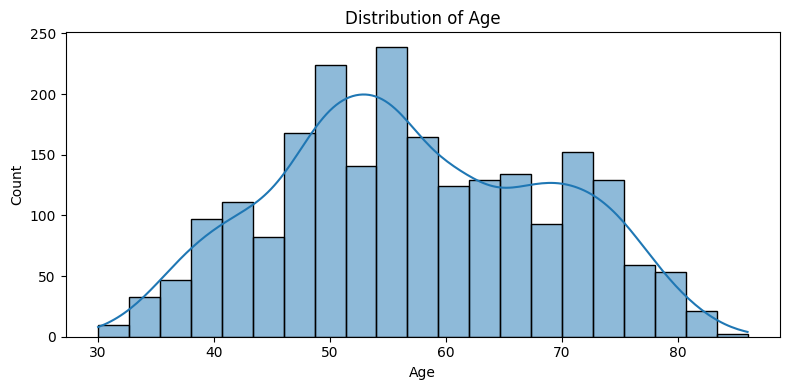

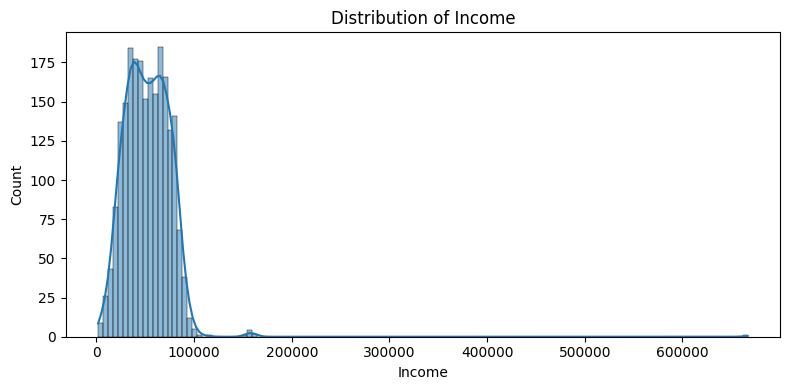

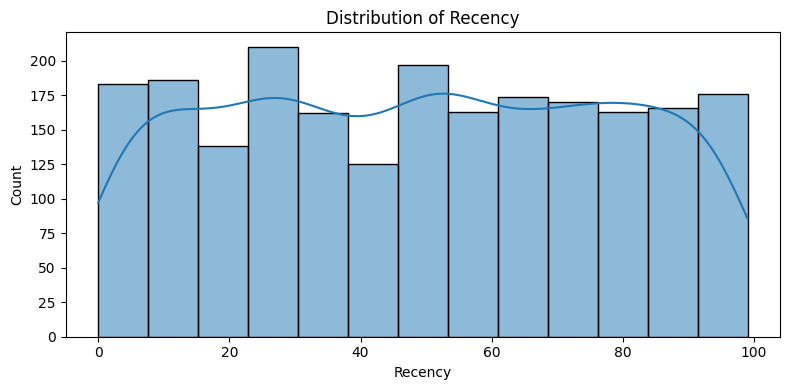

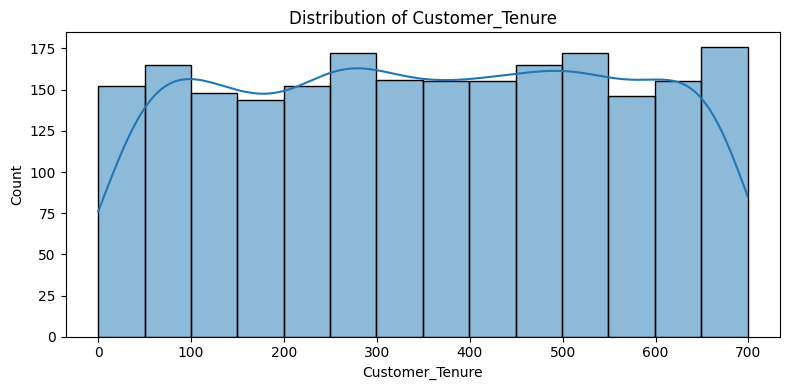

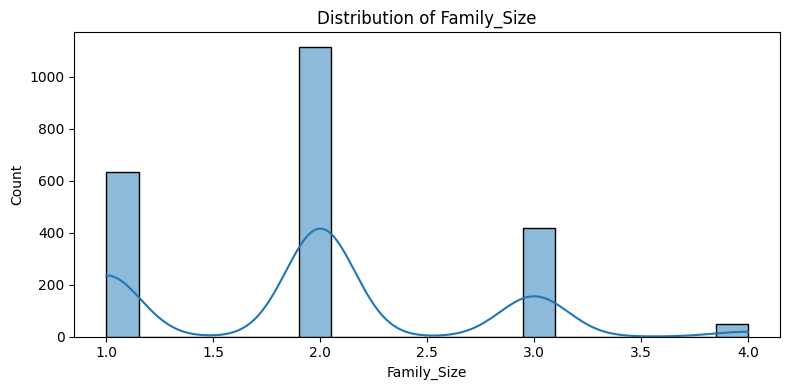

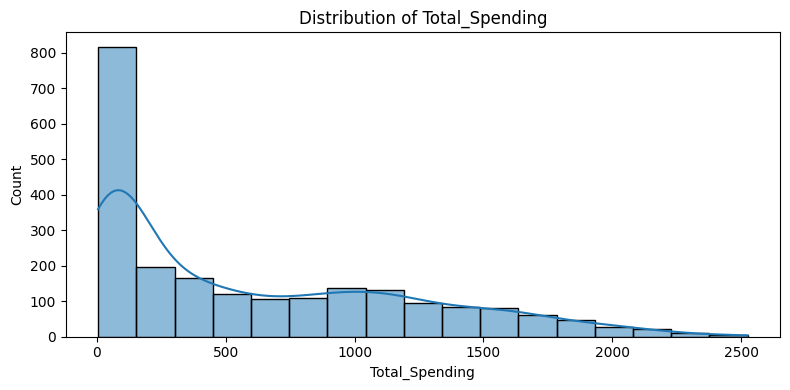

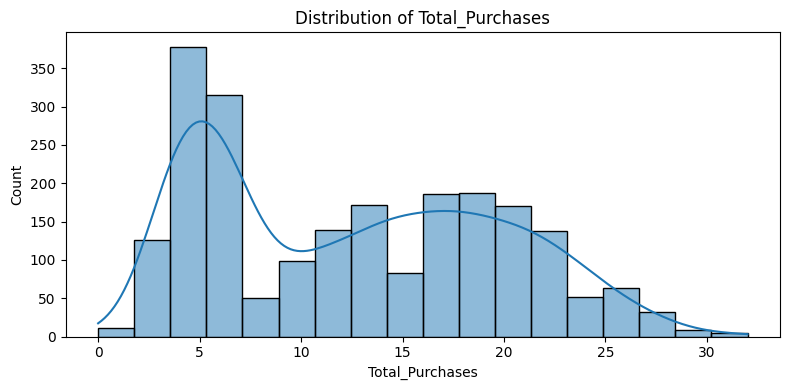

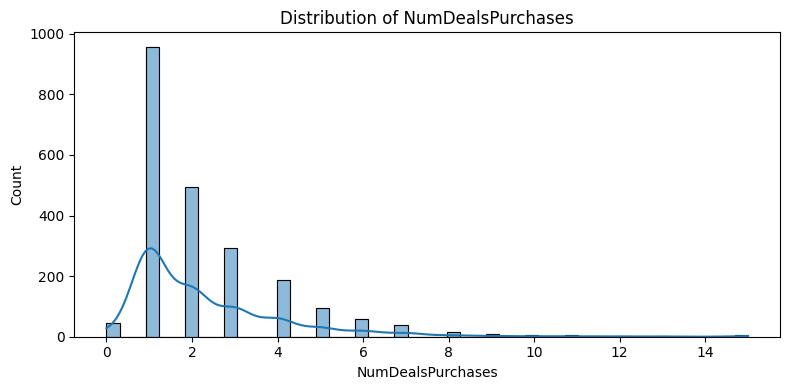

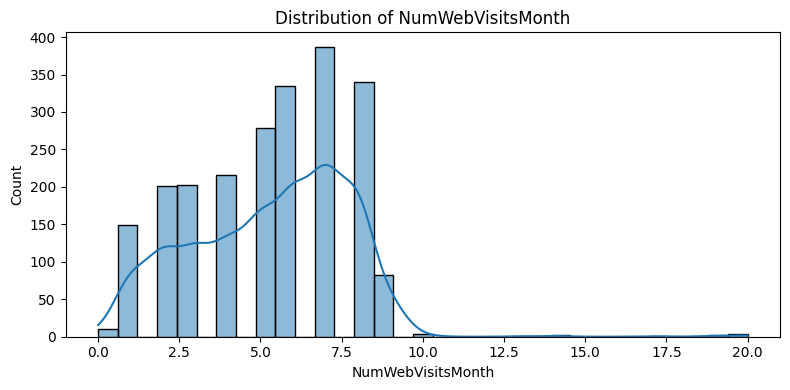

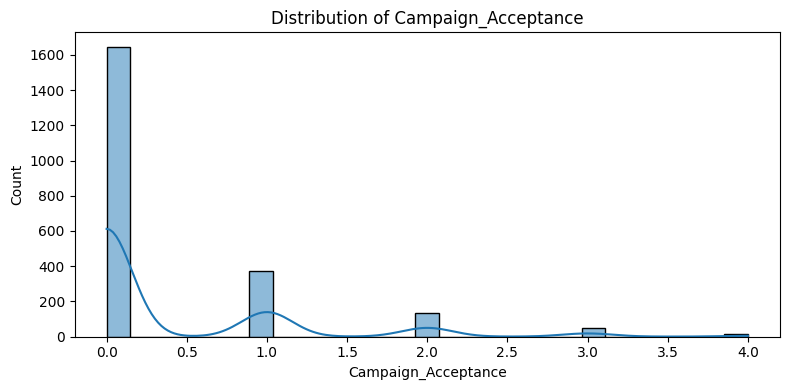

In [ ]:
# Distribution of clustering features
for col in df_cluster.columns:
    plt.figure(figsize=(8, 4))
    sb.histplot(df_cluster[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

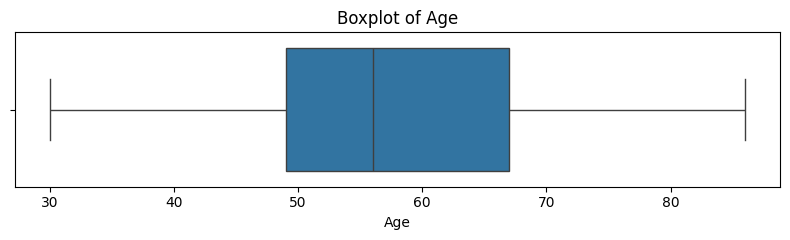

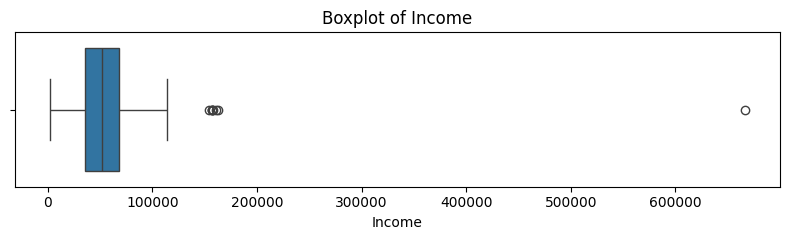

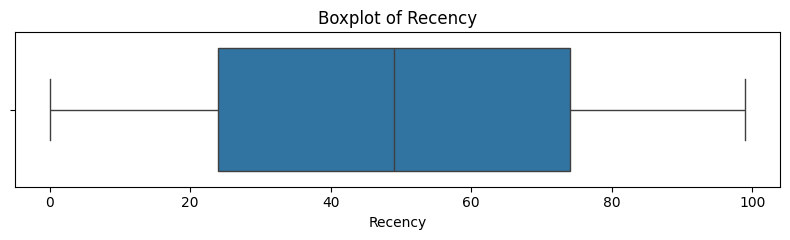

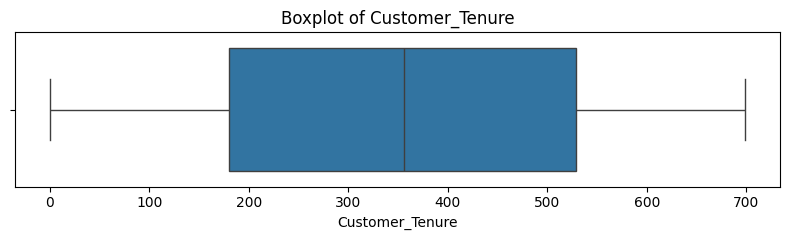

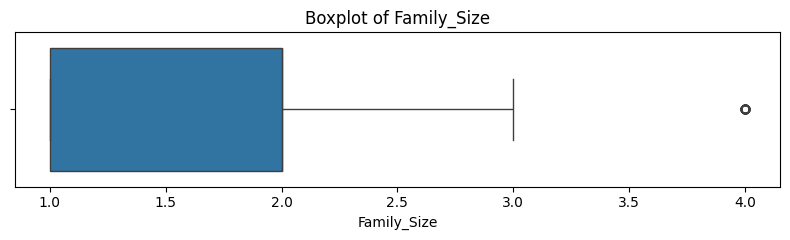

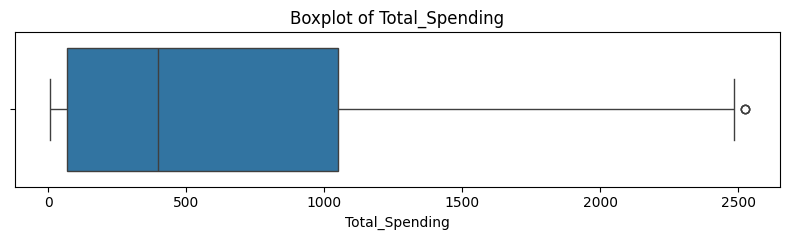

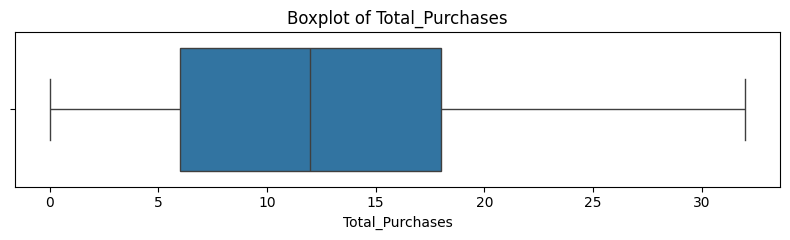

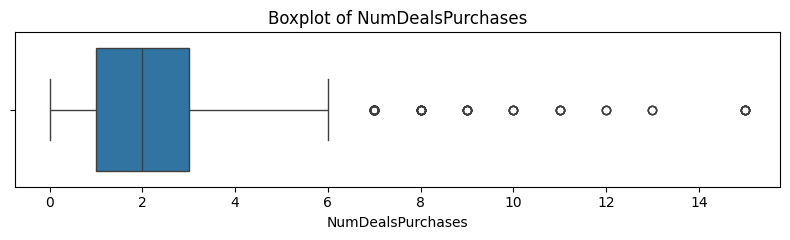

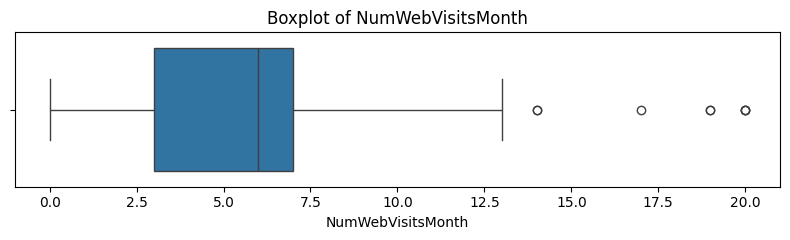

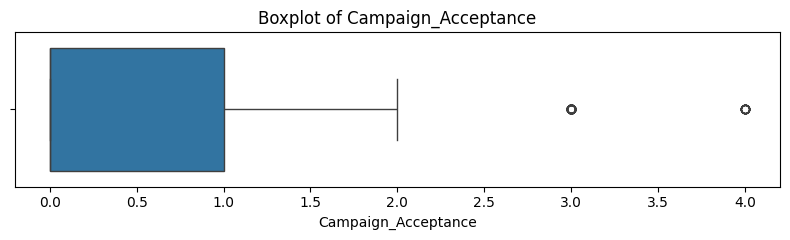

In [ ]:
# Boxplots for outlier inspection
for col in df_cluster.columns:
    plt.figure(figsize=(8, 2.5))
    sb.boxplot(x=df_cluster[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

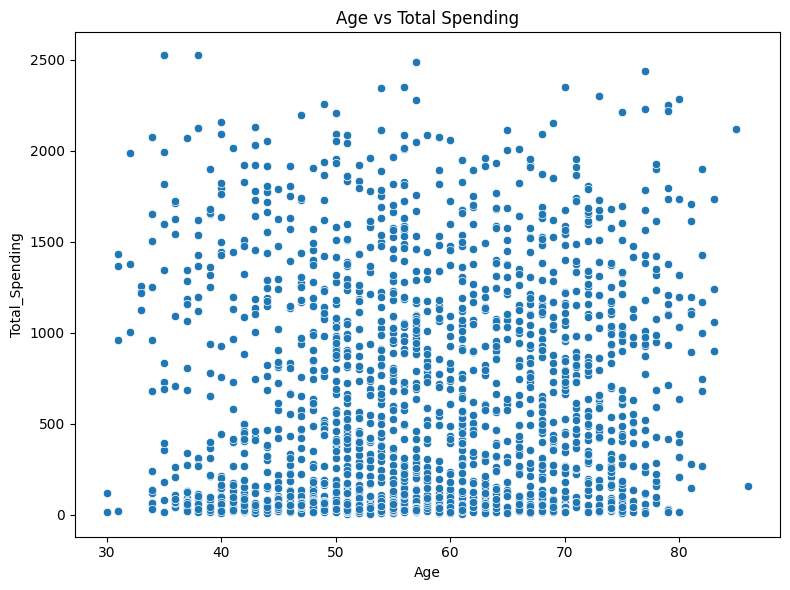

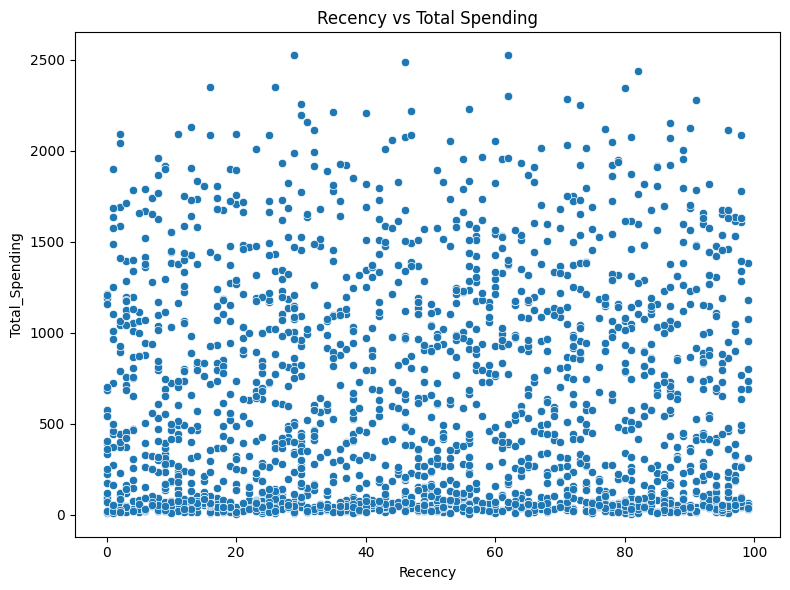

In [ ]:
plt.figure(figsize=(8, 6))
sb.scatterplot(data=df_cluster, x='Age', y='Total_Spending')
plt.title('Age vs Total Spending')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sb.scatterplot(data=df_cluster, x='Recency', y='Total_Spending')
plt.title('Recency vs Total Spending')
plt.tight_layout()
plt.show()

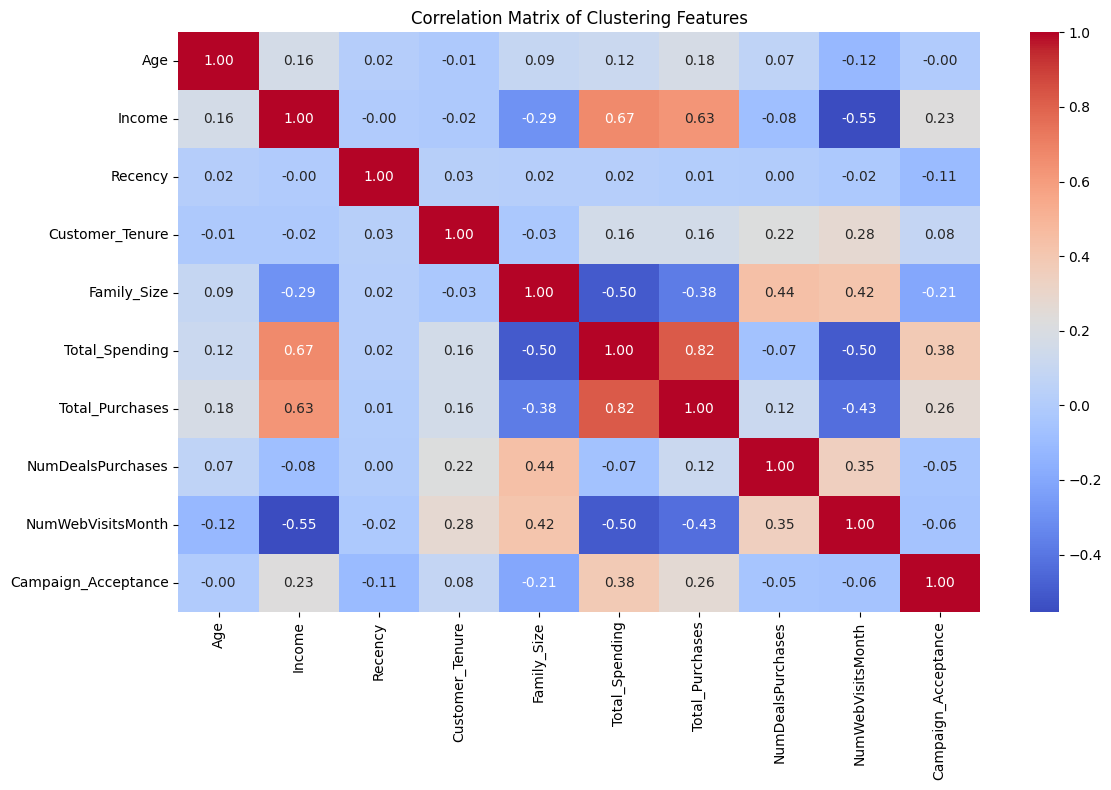

In [ ]:
plt.figure(figsize=(12, 8))
sb.heatmap(df_cluster.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Clustering Features')
plt.tight_layout()
plt.show()

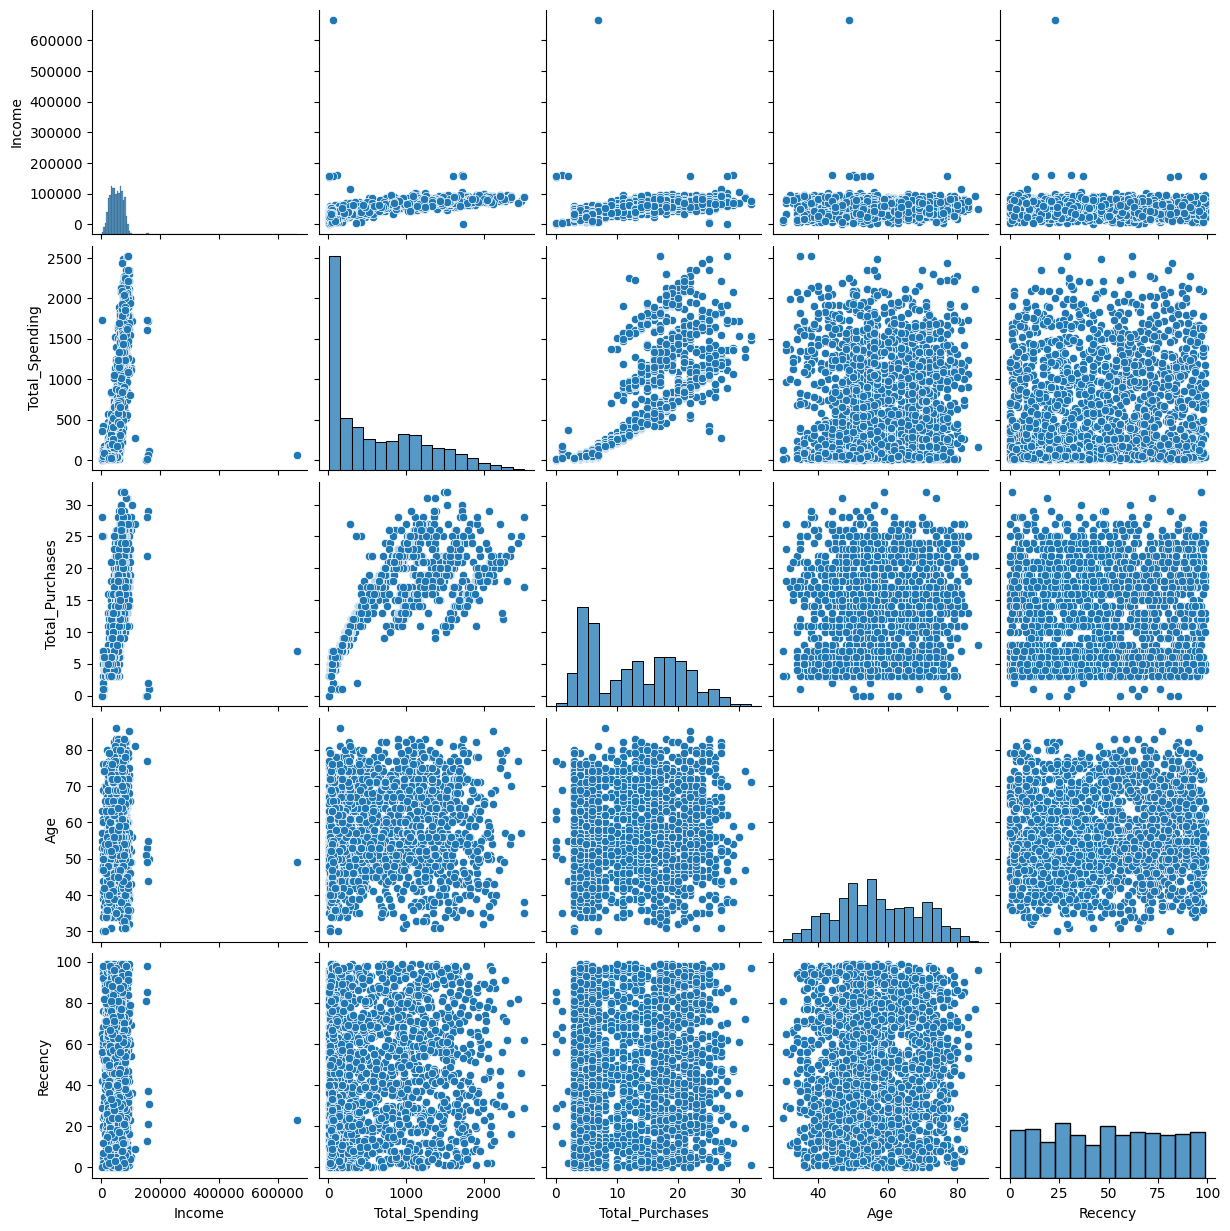

In [ ]:
selected = ['Income', 'Total_Spending', 'Total_Purchases', 'Age', 'Recency']
sb.pairplot(df_cluster[selected])
plt.show()

## 4. Outlier Treatment, Standardisation and PCA

In [ ]:
# Inspect the largest Income values before treatment
display(df_copy_income['Income'].sort_values(ascending=False).head(10))

,Income
2233,666666.0
617,162397.0
687,160803.0
1300,157733.0
164,157243.0
1653,157146.0
2132,156924.0
655,153924.0
1898,113734.0
646,105471.0


In [ ]:
# Remove the extreme Income outlier (666,666), which would distort distance-based models and PCA
df_copy_income = df_copy_income.loc[df_copy_income['Income'] < 200000].copy()
print('Rows after Income outlier removal:', len(df_copy_income))
display(df_copy_income['Income'].describe())

Rows after Income outlier removal: 2212


,Income
count,2212.000000
mean,51958.810579
std,21527.278844
min,1730.000000
25%,35233.500000
50%,51371.000000
75%,68487.000000
max,162397.000000


In [ ]:
# Re-create the final feature matrix after all cleaning
X = df_copy_income[cluster_features].copy()

# Standardise features because the clustering variables use different measurement scales
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=cluster_features,
    index=X.index
)

print('Scaled feature means (approximately 0):')
display(X_scaled.mean().round(4))
print('Scaled feature standard deviations (1):')
display(X_scaled.std(ddof=0).round(4))

Scaled feature means (approximately 0):


,0
Age,0.0
Income,-0.0
Recency,0.0
Customer_Tenure,-0.0
Family_Size,0.0
Total_Spending,0.0
Total_Purchases,-0.0
NumDealsPurchases,-0.0
NumWebVisitsMonth,0.0
Campaign_Acceptance,0.0


Scaled feature standard deviations (1):


,0
Age,1.0
Income,1.0
Recency,1.0
Customer_Tenure,1.0
Family_Size,1.0
Total_Spending,1.0
Total_Purchases,1.0
NumDealsPurchases,1.0
NumWebVisitsMonth,1.0
Campaign_Acceptance,1.0


Explained Variance Ratio: [0.3473 0.1589]
Total Explained Variance: 0.5061


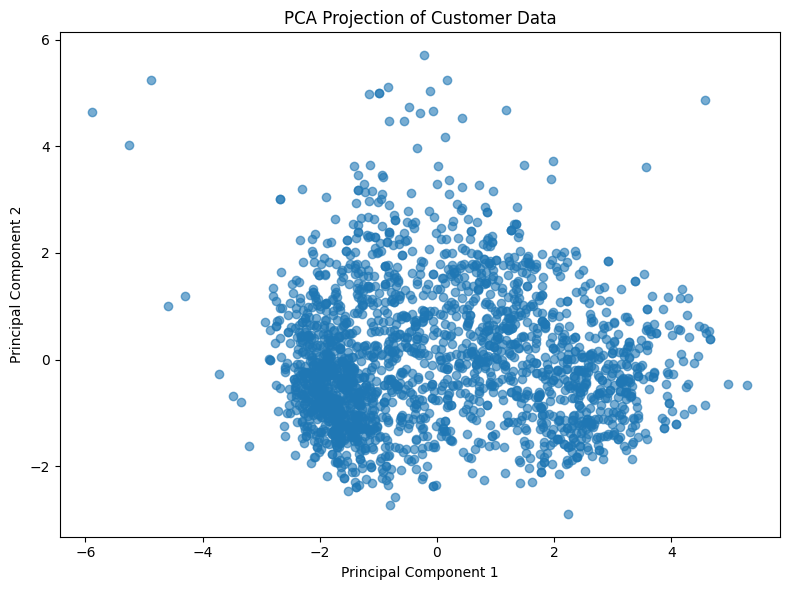

In [ ]:
# PCA is used for two-dimensional visualisation of the standardised feature space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Explained Variance Ratio:', np.round(pca.explained_variance_ratio_, 4))
print('Total Explained Variance:', round(pca.explained_variance_ratio_.sum(), 4))

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X.index)
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Customer Data')
plt.tight_layout()
plt.show()

In [ ]:
# PCA loadings show the contribution of the original features to the two visualisation components
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=cluster_features
)
display(loadings.round(3))

,PC1,PC2
Age,0.096,0.172
Income,0.476,0.061
Recency,-0.001,0.009
Customer_Tenure,0.013,0.513
Family_Size,-0.336,0.276
Total_Spending,0.489,0.171
Total_Purchases,0.449,0.284
NumDealsPurchases,-0.126,0.620
NumWebVisitsMonth,-0.384,0.330
Campaign_Acceptance,0.215,0.158


## 5. K-Means Clustering

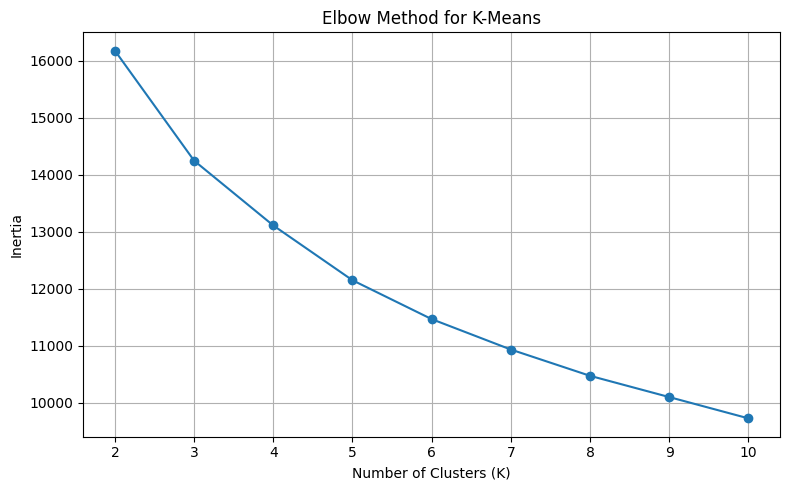

In [ ]:
# Elbow method
inertia = []
K = range(2, 11)
for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.grid(True)
plt.tight_layout()
plt.show()

,K,Silhouette_Score
0,2,0.2557
1,3,0.2101
2,4,0.2030
3,5,0.1553
4,6,0.1484
5,7,0.1424
6,8,0.1396
7,9,0.1392
8,10,0.1361


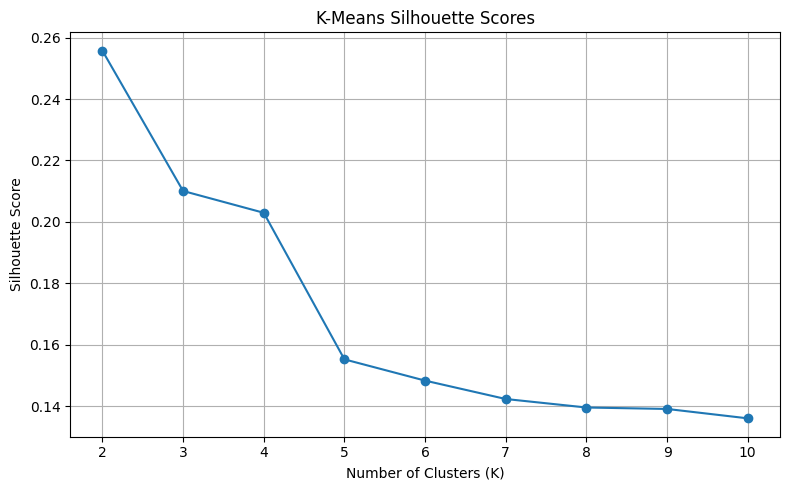

In [ ]:
# Silhouette analysis for candidate K values
silhouette_scores = []
K = range(2, 11)
for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

silhouette_table = pd.DataFrame({
    'K': list(K),
    'Silhouette_Score': silhouette_scores
})
display(silhouette_table.round(4))

plt.figure(figsize=(8, 5))
plt.plot(list(K), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('K-Means Silhouette Scores')
plt.grid(True)
plt.tight_layout()
plt.show()

**K-Means model selection.** Although K=2 has the highest silhouette coefficient, K=3 is retained because it provides a more informative and interpretable three-segment business solution while maintaining acceptable separation.

In [ ]:
# Final K-Means model: K = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_clustered = X.copy()
df_clustered['Cluster'] = cluster_labels

print('K-Means cluster sizes:')
display(pd.Series(cluster_labels).value_counts().sort_index())

K-Means cluster sizes:


,count
0,524
1,996
2,692


In [ ]:
kmeans_profile = df_clustered.groupby('Cluster').mean().round(2)
print('K-Means Customer Profiles:')
display(kmeans_profile)

K-Means Customer Profiles:


,Age,Income,Recency,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Campaign_Acceptance
Cluster,,,,,,,,,,
0,60.23,55158.79,49.30,466.10,2.33,702.15,16.55,4.69,6.47,0.37
1,54.33,34463.38,48.86,309.25,2.20,99.86,5.96,1.84,6.35,0.16
2,58.68,74716.99,49.03,332.61,1.30,1265.74,19.06,1.24,2.98,0.69


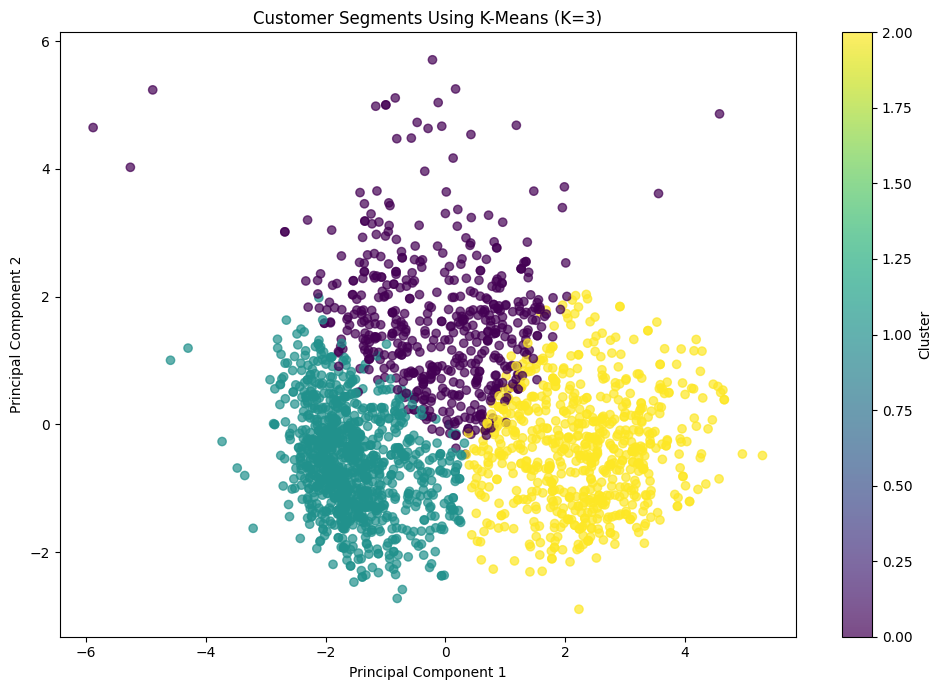

In [ ]:
pca_kmeans = pca_df.copy()
pca_kmeans['Cluster'] = cluster_labels

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_kmeans['PC1'],
    pca_kmeans['PC2'],
    c=pca_kmeans['Cluster'],
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments Using K-Means (K=3)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

In [ ]:
kmeans_centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=cluster_features
).round(2)
print('Standardised K-Means Centroids:')
display(kmeans_centroids)

kmeans_silhouette = silhouette_score(X_scaled, cluster_labels)
kmeans_db = davies_bouldin_score(X_scaled, cluster_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, cluster_labels)

print(f'Silhouette Score: {kmeans_silhouette:.4f}')
print(f'Davies-Bouldin Index: {kmeans_db:.4f}')
print(f'Calinski-Harabasz Score: {kmeans_ch:.2f}')

Standardised K-Means Centroids:


,Age,Income,Recency,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Campaign_Acceptance
0,0.27,0.15,0.01,0.56,0.51,0.16,0.55,1.23,0.47,-0.01
1,-0.24,-0.81,-0.01,-0.22,0.33,-0.84,-0.92,-0.25,0.42,-0.29
2,0.14,1.06,0.00,-0.10,-0.87,1.09,0.90,-0.57,-0.97,0.43


Silhouette Score: 0.2101
Davies-Bouldin Index: 1.7308
Calinski-Harabasz Score: 610.15


## 6. DBSCAN Clustering

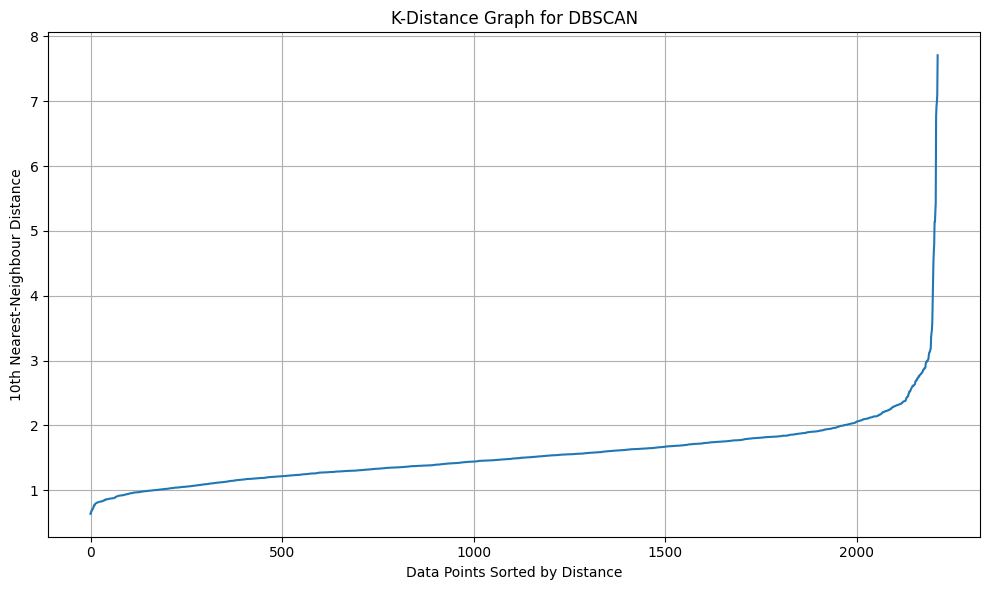

In [ ]:
# K-distance graph to support DBSCAN parameter exploration
# Use 10 neighbours because the final selected min_samples value is 10.
min_samples_kdist = 10
neighbors = NearestNeighbors(n_neighbors=min_samples_kdist)
distances, _ = neighbors.fit(X_scaled).kneighbors(X_scaled)
k_distances = np.sort(distances[:, min_samples_kdist - 1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel('10th Nearest-Neighbour Distance')
plt.title('K-Distance Graph for DBSCAN')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Systematic DBSCAN parameter search
eps_values = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
min_samples_values = [5, 10, 15, 20]
results = []

for min_samples in min_samples_values:
    for eps in eps_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        n_clusters_candidate = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise_candidate = int((labels == -1).sum())
        results.append({
            'min_samples': min_samples,
            'eps': eps,
            'Clusters': n_clusters_candidate,
            'Noise_Points': n_noise_candidate,
            'Noise_Percentage': round(n_noise_candidate / len(labels) * 100, 2)
        })

results_df = pd.DataFrame(results)
display(results_df)

,min_samples,eps,Clusters,Noise_Points,Noise_Percentage
0,5,1.0,28,1450,65.55
1,5,1.2,20,901,40.73
2,5,1.4,16,516,23.33
3,5,1.6,5,232,10.49
4,5,1.8,1,125,5.65
5,5,2.0,1,66,2.98
6,10,1.0,6,1822,82.37
7,10,1.2,8,1328,60.04
8,10,1.4,8,820,37.07
9,10,1.6,3,394,17.81


In [ ]:
# Evaluate promising DBSCAN combinations using non-noise observations
candidates = [
    {'min_samples': 5, 'eps': 1.6},
    {'min_samples': 10, 'eps': 1.6},
    {'min_samples': 10, 'eps': 1.8}
]

evaluation_results = []
for params in candidates:
    labels = DBSCAN(**params).fit_predict(X_scaled)
    mask = labels != -1
    X_non_noise = X_scaled.loc[mask]
    labels_non_noise = labels[mask]
    n_clusters_candidate = len(set(labels_non_noise))

    row = {
        'min_samples': params['min_samples'],
        'eps': params['eps'],
        'Clusters': n_clusters_candidate,
        'Noise_Points': int((labels == -1).sum()),
        'Noise_Percentage': round((labels == -1).sum() / len(labels) * 100, 2)
    }

    if n_clusters_candidate >= 2:
        row.update({
            'Silhouette_Score': silhouette_score(X_non_noise, labels_non_noise),
            'Davies_Bouldin_Index': davies_bouldin_score(X_non_noise, labels_non_noise),
            'Calinski_Harabasz_Score': calinski_harabasz_score(X_non_noise, labels_non_noise)
        })
    else:
        row.update({'Silhouette_Score': np.nan, 'Davies_Bouldin_Index': np.nan, 'Calinski_Harabasz_Score': np.nan})
    evaluation_results.append(row)

evaluation_df = pd.DataFrame(evaluation_results)
display(evaluation_df.round(4))

,min_samples,eps,Clusters,Noise_Points,Noise_Percentage,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Score
0,5,1.6,5,232,10.49,0.1409,1.0126,20.1123
1,10,1.6,3,394,17.81,0.0013,1.3596,23.8801
2,10,1.8,2,177,8.00,0.3119,0.7549,19.0977


In [ ]:
# Final DBSCAN model
dbscan_final = DBSCAN(eps=1.8, min_samples=10)
dbscan_labels = dbscan_final.fit_predict(X_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = int((dbscan_labels == -1).sum())

print('DBSCAN Cluster Distribution:')
display(pd.Series(dbscan_labels).value_counts().sort_index())
print('Number of Clusters:', n_clusters_dbscan)
print('Noise Points:', n_noise_dbscan)
print(f'Noise Percentage: {n_noise_dbscan / len(dbscan_labels) * 100:.2f}%')

DBSCAN Cluster Distribution:


,count
-1,177
0,2029
1,6


Number of Clusters: 2
Noise Points: 177
Noise Percentage: 8.00%


In [ ]:
df_dbscan = X.copy()
df_dbscan['DBSCAN_Cluster'] = dbscan_labels

dbscan_clustered = df_dbscan.loc[df_dbscan['DBSCAN_Cluster'] != -1].copy()
dbscan_noise = df_dbscan.loc[df_dbscan['DBSCAN_Cluster'] == -1].copy()

cluster_profile_dbscan = dbscan_clustered.groupby('DBSCAN_Cluster')[cluster_features].mean()
noise_profile_dbscan = pd.DataFrame(
    [dbscan_noise[cluster_features].mean()],
    index=['Noise']
)
dbscan_comparison_profile = pd.concat([cluster_profile_dbscan, noise_profile_dbscan])

print('DBSCAN Cluster and Noise Profiles:')
display(dbscan_comparison_profile.round(2))

DBSCAN Cluster and Noise Profiles:


,Age,Income,Recency,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Campaign_Acceptance
0,57.01,50602.09,49.26,349.12,1.96,562.21,12.10,2.22,5.27,0.26
1,42.33,81947.83,45.50,129.50,1.00,1835.17,19.00,1.00,2.00,3.00
Noise,58.47,66494.75,46.33,413.97,1.88,1082.19,17.66,3.59,6.08,1.67


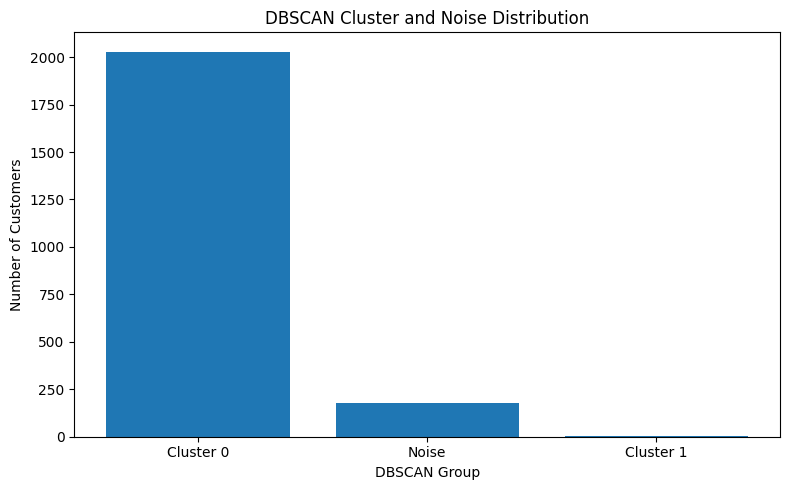

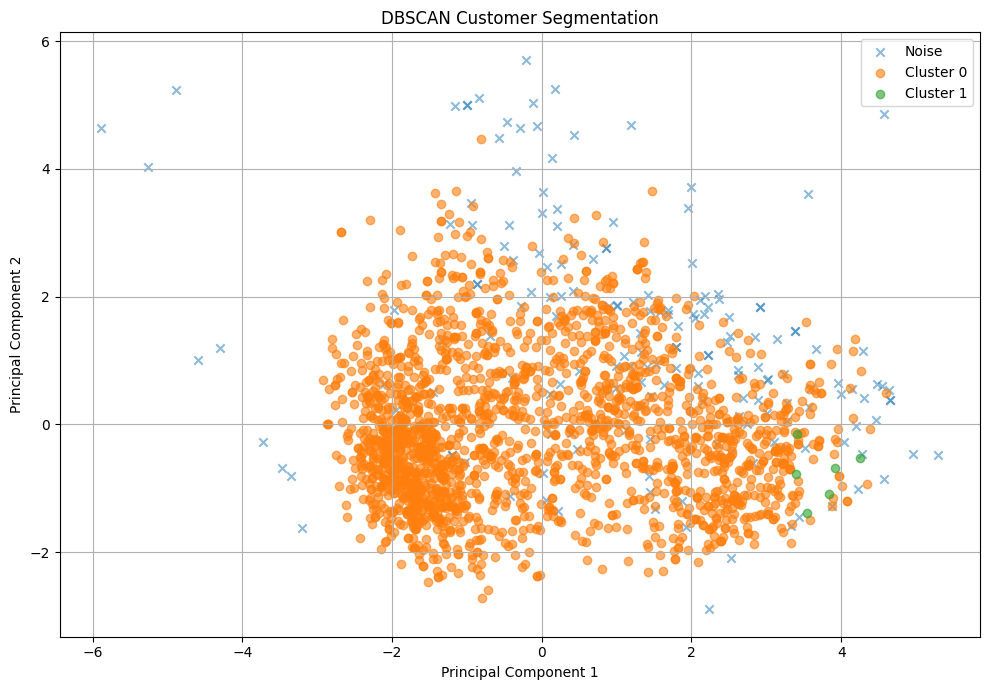

In [ ]:
# DBSCAN distribution
labels_for_plot = pd.Series(dbscan_labels).replace({-1: 'Noise', 0: 'Cluster 0', 1: 'Cluster 1'})
cluster_counts_plot = labels_for_plot.value_counts()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts_plot.index, cluster_counts_plot.values)
plt.xlabel('DBSCAN Group')
plt.ylabel('Number of Customers')
plt.title('DBSCAN Cluster and Noise Distribution')
plt.tight_layout()
plt.show()

# PCA visualisation using the PCA model already fitted to X_scaled
plt.figure(figsize=(10, 7))
noise_mask = dbscan_labels == -1
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], label='Noise', alpha=0.5, marker='x')
for cluster in sorted(set(dbscan_labels)):
    if cluster != -1:
        cluster_mask = dbscan_labels == cluster
        plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], label=f'Cluster {cluster}', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Customer Segmentation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

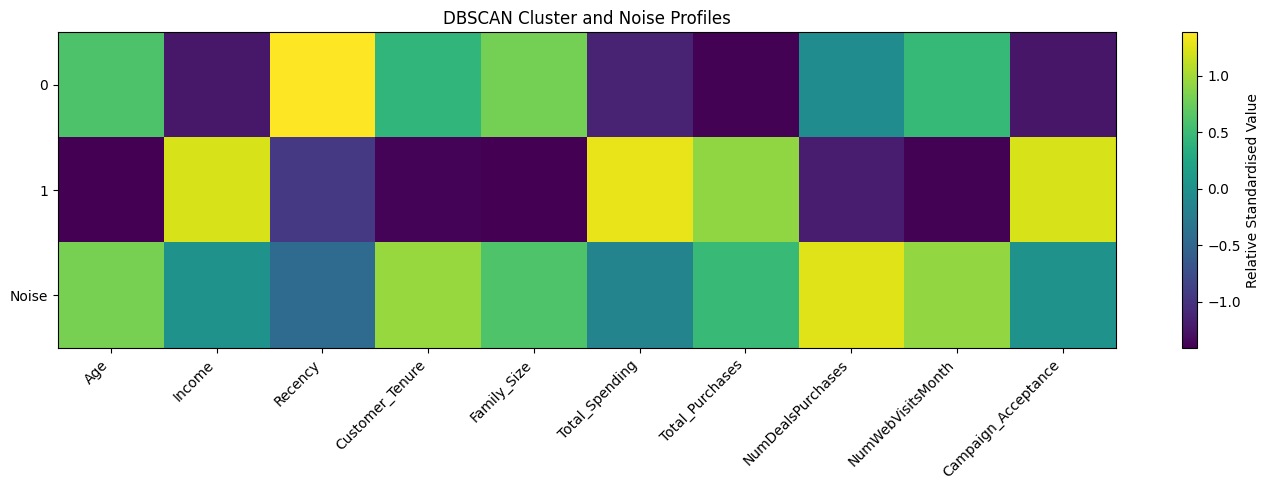

In [ ]:
# Heatmap of DBSCAN profiles
scaler_heatmap = StandardScaler()
dbscan_profile_scaled = pd.DataFrame(
    scaler_heatmap.fit_transform(dbscan_comparison_profile),
    index=dbscan_comparison_profile.index,
    columns=dbscan_comparison_profile.columns
)

plt.figure(figsize=(14, 5))
plt.imshow(dbscan_profile_scaled, aspect='auto')
plt.colorbar(label='Relative Standardised Value')
plt.xticks(range(len(cluster_features)), cluster_features, rotation=45, ha='right')
plt.yticks(range(len(dbscan_profile_scaled.index)), dbscan_profile_scaled.index)
plt.title('DBSCAN Cluster and Noise Profiles')
plt.tight_layout()
plt.show()

In [ ]:
# Final DBSCAN evaluation (noise excluded from internal validation metrics)
mask_dbscan = dbscan_labels != -1
X_non_noise = X_scaled.loc[mask_dbscan]
labels_non_noise = dbscan_labels[mask_dbscan]

dbscan_silhouette = silhouette_score(X_non_noise, labels_non_noise)
dbscan_db = davies_bouldin_score(X_non_noise, labels_non_noise)
dbscan_ch = calinski_harabasz_score(X_non_noise, labels_non_noise)

print('Final DBSCAN Evaluation')
print(f'Number of Clusters: {n_clusters_dbscan}')
print(f'Noise Points: {n_noise_dbscan}')
print(f'Noise Percentage: {n_noise_dbscan / len(dbscan_labels) * 100:.2f}%')
print(f'Silhouette Score: {dbscan_silhouette:.4f}')
print(f'Davies-Bouldin Index: {dbscan_db:.4f}')
print(f'Calinski-Harabasz Score: {dbscan_ch:.2f}')

Final DBSCAN Evaluation
Number of Clusters: 2
Noise Points: 177
Noise Percentage: 8.00%
Silhouette Score: 0.3119
Davies-Bouldin Index: 0.7549
Calinski-Harabasz Score: 19.10


**DBSCAN interpretation.** Internal validation scores are calculated only on non-noise observations. They should therefore not be interpreted as directly equivalent to K-Means and GMM scores without considering DBSCAN's 8% noise rate and highly imbalanced cluster sizes.

## 7. Gaussian Mixture Model (GMM)

In [ ]:
# Compare GMM solutions from 2 to 10 components
gmm_evaluation = []
for k in range(2, 11):
    model = GaussianMixture(n_components=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    gmm_evaluation.append({
        'Components': k,
        'AIC': model.aic(X_scaled),
        'BIC': model.bic(X_scaled),
        'Silhouette': silhouette_score(X_scaled, labels),
        'Davies_Bouldin': davies_bouldin_score(X_scaled, labels),
        'Calinski_Harabasz': calinski_harabasz_score(X_scaled, labels)
    })

gmm_evaluation_df = pd.DataFrame(gmm_evaluation)
display(gmm_evaluation_df.round(4))

,Components,AIC,BIC,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,45956.7010,46703.6175,0.2109,1.7170,642.2522
1,3,24310.8847,25434.1102,0.1580,2.5166,378.6164
2,4,22909.6183,24409.1529,0.0973,2.3172,303.2710
3,5,22748.4213,24624.2649,0.1199,2.4827,280.6127
4,6,14170.1314,16422.2841,0.0751,3.1307,171.7363
5,7,15195.7058,17824.1676,0.0373,3.0325,131.6927
6,8,11704.1947,14708.9655,0.0901,3.2784,155.2605
7,9,18352.7118,21733.7917,0.0859,2.4678,172.9668
8,10,8719.6758,12477.0647,0.0423,2.8669,138.4293


**GMM model selection.** AIC/BIC continue to favour more complex mixtures, whereas the internal clustering metrics are strongest for two components. A two-component GMM is therefore retained as a parsimonious and interpretable solution rather than selecting the model from AIC/BIC alone.

In [ ]:
# Final two-component GMM
gmm_final = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm_final.fit_predict(X_scaled)

print('GMM Cluster Sizes:')
display(pd.Series(gmm_labels).value_counts().sort_index())

GMM Cluster Sizes:


,count
0,1225
1,987


In [ ]:
df_gmm = X.copy()
df_gmm['GMM_Cluster'] = gmm_labels

gmm_profile = df_gmm.groupby('GMM_Cluster')[cluster_features].mean()
print('GMM Cluster Profiles:')
display(gmm_profile.round(2))

GMM Cluster Profiles:


,Age,Income,Recency,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Campaign_Acceptance
GMM_Cluster,,,,,,,,,,
0,58.88,65889.82,49.03,380.79,1.70,1023.73,18.03,2.60,4.49,0.55
1,54.86,34668.55,49.00,320.11,2.25,90.38,5.79,1.98,6.36,0.17


In [ ]:
# Membership probabilities and confidence
gmm_probabilities = gmm_final.predict_proba(X_scaled)
df_gmm['Probability_Cluster_0'] = gmm_probabilities[:, 0]
df_gmm['Probability_Cluster_1'] = gmm_probabilities[:, 1]
df_gmm['GMM_Confidence'] = gmm_probabilities.max(axis=1)

print('Average membership probabilities:')
display(df_gmm[['Probability_Cluster_0', 'Probability_Cluster_1']].mean().round(4))
print('GMM confidence summary:')
display(df_gmm['GMM_Confidence'].describe().round(4))

Average membership probabilities:


,0
Probability_Cluster_0,0.5557
Probability_Cluster_1,0.4443


GMM confidence summary:


,GMM_Confidence
count,2212.0000
mean,0.9894
std,0.0507
min,0.5164
25%,0.9999
50%,1.0000
75%,1.0000
max,1.0000


In [ ]:
gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
gmm_db = davies_bouldin_score(X_scaled, gmm_labels)
gmm_ch = calinski_harabasz_score(X_scaled, gmm_labels)

print('Final GMM Evaluation')
print('Components:', gmm_final.n_components)
print(f'Silhouette: {gmm_silhouette:.4f}')
print(f'Davies-Bouldin: {gmm_db:.4f}')
print(f'Calinski-Harabasz: {gmm_ch:.2f}')

Final GMM Evaluation
Components: 2
Silhouette: 0.2109
Davies-Bouldin: 1.7170
Calinski-Harabasz: 642.25


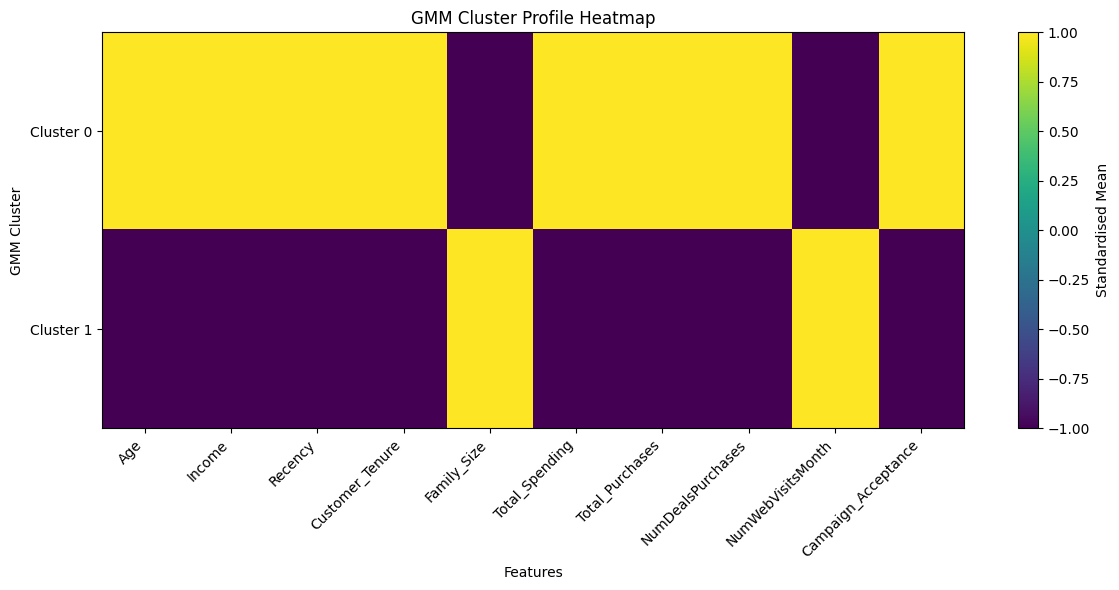

In [ ]:
# GMM profile heatmap
gmm_profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(gmm_profile),
    index=gmm_profile.index,
    columns=gmm_profile.columns
)

plt.figure(figsize=(12, 6))
plt.imshow(gmm_profile_scaled, aspect='auto')
plt.xticks(range(len(gmm_profile_scaled.columns)), gmm_profile_scaled.columns, rotation=45, ha='right')
plt.yticks(range(len(gmm_profile_scaled.index)), [f'Cluster {i}' for i in gmm_profile_scaled.index])
plt.xlabel('Features')
plt.ylabel('GMM Cluster')
plt.title('GMM Cluster Profile Heatmap')
plt.colorbar(label='Standardised Mean')
plt.tight_layout()
plt.show()

## 8. Model Comparison

In [ ]:
comparison = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Score'],
    'K-Means': [kmeans_silhouette, kmeans_db, kmeans_ch],
    'DBSCAN': [dbscan_silhouette, dbscan_db, dbscan_ch],
    'GMM': [gmm_silhouette, gmm_db, gmm_ch]
})
print('Final Model Comparison:')
display(comparison.round(4))

Final Model Comparison:


,Metric,K-Means,DBSCAN,GMM
0,Silhouette Score,0.2101,0.3119,0.2109
1,Davies-Bouldin Index,1.7308,0.7549,1.7170
2,Calinski-Harabasz Score,610.1472,19.0977,642.2522


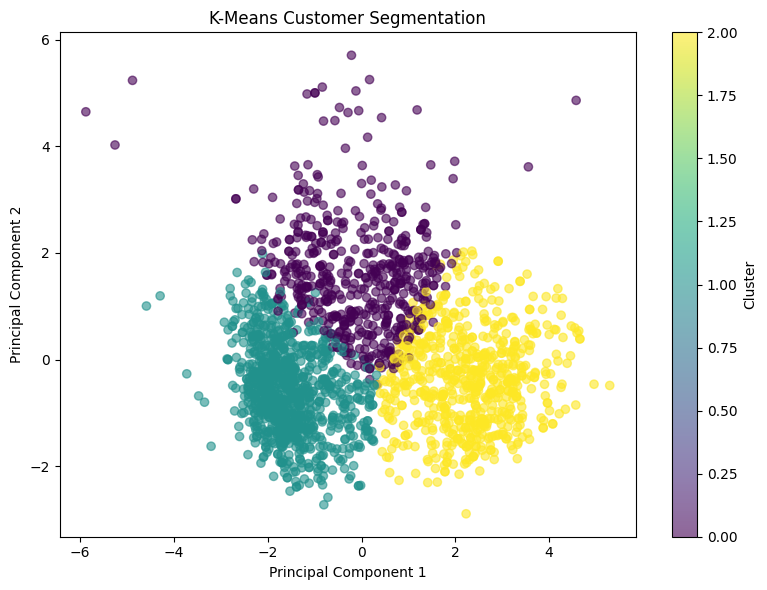

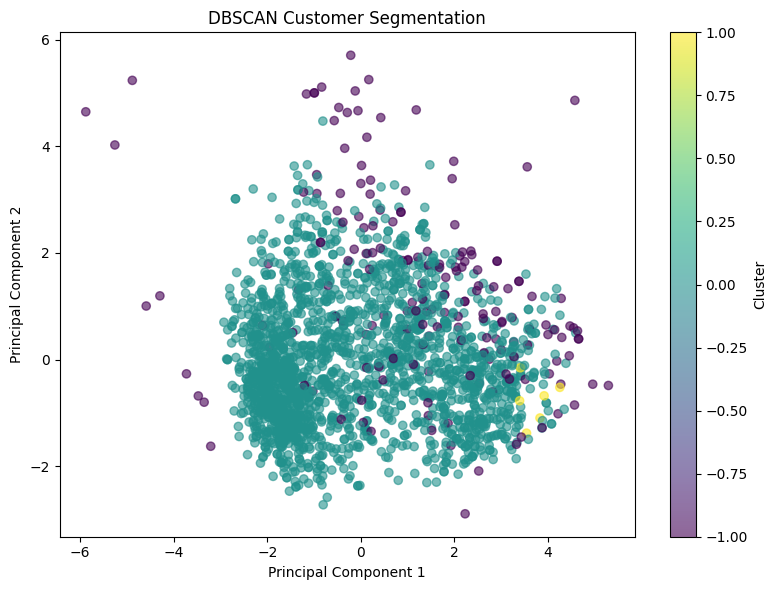

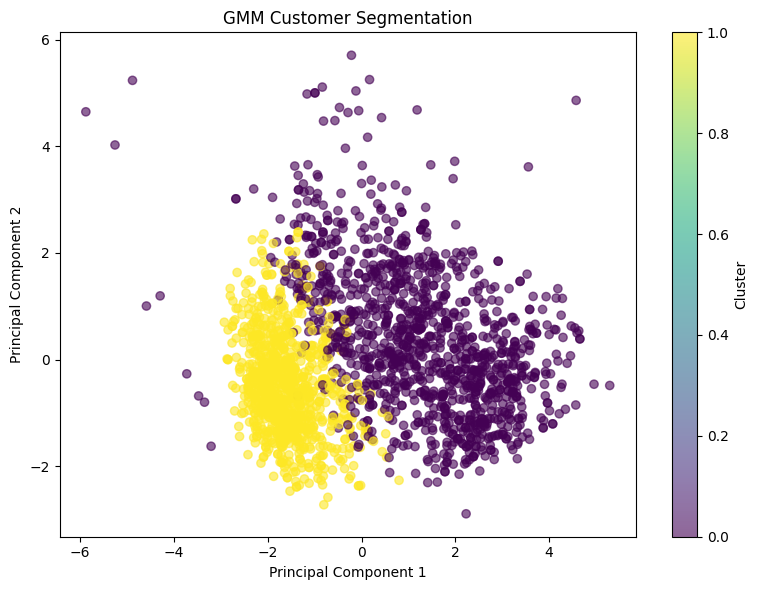

In [ ]:
# Visual comparison in the same PCA space
for title, labels in [
    ('K-Means Customer Segmentation', cluster_labels),
    ('DBSCAN Customer Segmentation', dbscan_labels),
    ('GMM Customer Segmentation', gmm_labels)
]:
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, alpha=0.6)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(title)
    plt.colorbar(scatter, label='Cluster')
    plt.tight_layout()
    plt.show()

In [ ]:
print('K-Means')
display(pd.Series(cluster_labels).value_counts().sort_index())
print('DBSCAN')
display(pd.Series(dbscan_labels).value_counts().sort_index())
print('GMM')
display(pd.Series(gmm_labels).value_counts().sort_index())

K-Means


,count
0,524
1,996
2,692


DBSCAN


,count
-1,177
0,2029
1,6


GMM


,count
0,1225
1,987


**Overall interpretation.** DBSCAN achieves the strongest silhouette and Davies-Bouldin values on its non-noise subset, but produces one dominant cluster, one very small cluster, and noise observations. GMM produces two broad and stable customer groups. K-Means with K=3 is retained as the most useful business segmentation because it provides three distinct, interpretable customer segments despite a lower silhouette score than the two-cluster alternatives.

## 9. Stability Analysis

In [ ]:
seeds = [1, 10, 42, 100, 500]

kmeans_results = []
for seed in seeds:
    labels = KMeans(n_clusters=3, random_state=seed, n_init=10).fit_predict(X_scaled)
    kmeans_results.append(labels)

print('K-Means stability (Adjusted Rand Index):')
for i in range(1, len(kmeans_results)):
    score = adjusted_rand_score(kmeans_results[0], kmeans_results[i])
    print(f'Seed {seeds[0]} vs Seed {seeds[i]}: ARI = {score:.4f}')

K-Means stability (Adjusted Rand Index):
Seed 1 vs Seed 10: ARI = 0.9771
Seed 1 vs Seed 42: ARI = 0.9763
Seed 1 vs Seed 100: ARI = 0.9663
Seed 1 vs Seed 500: ARI = 0.9547


In [ ]:
gmm_results = []
for seed in seeds:
    labels = GaussianMixture(n_components=2, random_state=seed).fit_predict(X_scaled)
    gmm_results.append(labels)

print('GMM stability (Adjusted Rand Index):')
for i in range(1, len(gmm_results)):
    score = adjusted_rand_score(gmm_results[0], gmm_results[i])
    print(f'Seed {seeds[0]} vs Seed {seeds[i]}: ARI = {score:.4f}')

GMM stability (Adjusted Rand Index):
Seed 1 vs Seed 10: ARI = 1.0000
Seed 1 vs Seed 42: ARI = 1.0000
Seed 1 vs Seed 100: ARI = 1.0000
Seed 1 vs Seed 500: ARI = 1.0000


## 10. Dashboard Data Export (Optional Execution Section)

The following cells support the Streamlit dashboard. They are not part of the clustering methodology itself.

In [ ]:
import pickle

data = {
    'X_scaled': X_scaled,
    'kmeans_labels': cluster_labels,
    'dbscan_labels': dbscan_labels,
    'gmm_labels': gmm_labels
}

with open('segmentation_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print('Dashboard data saved successfully.')

Dashboard data saved successfully.


In [ ]:
# Run only when launching the dashboard in Google Colab
!pip install streamlit plotly pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 105.5 MB/s eta 0:00:00


**Security note:** do not hard-code or submit a personal ngrok authentication token in the notebook. Enter it only in your private runtime when you need to launch the dashboard.

In [57]:
# ============================================================
# RELIABLE STREAMLIT + CLOUDFLARE LAUNCHER FOR GOOGLE COLAB
# ============================================================

import os
import time
import subprocess
import re
import requests

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

DASHBOARD_FILE = "colab_streamlit_dashboard_2.py"
DATA_FILE = "segmentation_data.pkl"
PORT = 8501

# ------------------------------------------------------------
# CHECK REQUIRED FILES
# ------------------------------------------------------------

if not os.path.exists(DASHBOARD_FILE):
    raise FileNotFoundError(
        f"{DASHBOARD_FILE} was not found. "
        "Please upload it to Colab."
    )

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"{DATA_FILE} was not found. "
        "Please run the clustering analysis first "
        "or upload segmentation_data.pkl."
    )

print("✓ Dashboard file found")
print("✓ Segmentation data found")

# ------------------------------------------------------------
# STOP OLD PROCESSES
# ------------------------------------------------------------

os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")

time.sleep(2)

# ------------------------------------------------------------
# INSTALL CLOUDFLARED IF NEEDED
# ------------------------------------------------------------

if not os.path.exists("/usr/local/bin/cloudflared"):

    print("Installing Cloudflare tunnel...")

    os.system(
        "wget -q "
        "https://github.com/cloudflare/cloudflared/releases/latest/download/"
        "cloudflared-linux-amd64 "
        "-O /usr/local/bin/cloudflared"
    )

    os.system("chmod +x /usr/local/bin/cloudflared")

    print("✓ Cloudflare installed")

else:
    print("✓ Cloudflare already installed")

# ------------------------------------------------------------
# START STREAMLIT
# ------------------------------------------------------------

streamlit_log = open("/tmp/streamlit.log", "w")

streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        DASHBOARD_FILE,
        f"--server.port={PORT}",
        "--server.address=0.0.0.0",
        "--server.headless=true",
        "--browser.gatherUsageStats=false"
    ],
    stdout=streamlit_log,
    stderr=subprocess.STDOUT
)

print("Starting Streamlit...")

time.sleep(6)

# ------------------------------------------------------------
# CHECK STREAMLIT
# ------------------------------------------------------------

if streamlit_process.poll() is not None:

    streamlit_log.close()

    print("❌ Streamlit failed to start.")

    with open("/tmp/streamlit.log", "r") as f:
        print(f.read())

    raise RuntimeError("Streamlit failed to start.")

print("✓ Streamlit started successfully")

# ------------------------------------------------------------
# TEST STREAMLIT LOCALLY
# ------------------------------------------------------------

try:

    response = requests.get(
        f"http://127.0.0.1:{PORT}",
        timeout=10
    )

    print(
        f"✓ Local Streamlit server responding "
        f"(HTTP {response.status_code})"
    )

except Exception as e:

    print("❌ Streamlit is running but cannot be reached.")
    print(e)

    raise

# ------------------------------------------------------------
# START CLOUDFLARE TUNNEL
# ------------------------------------------------------------

print("Starting Cloudflare tunnel...")

cloudflare_process = subprocess.Popen(
    [
        "cloudflared",
        "tunnel",
        "--url",
        f"http://127.0.0.1:{PORT}",
        "--no-autoupdate"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

# ------------------------------------------------------------
# FIND PUBLIC URL
# ------------------------------------------------------------

public_url = None

for i in range(60):

    line = cloudflare_process.stdout.readline()

    if line:
        print(line.strip())

        match = re.search(
            r"https://[a-zA-Z0-9\-]+\.trycloudflare\.com",
            line
        )

        if match:
            public_url = match.group(0)
            break

    time.sleep(1)

# ------------------------------------------------------------
# SHOW RESULT
# ------------------------------------------------------------

if public_url:

    print("\n")
    print("=" * 60)
    print("✓ DASHBOARD READY")
    print("=" * 60)

    print("\nOpen this link in Chrome:\n")
    print(public_url)

    print("\nKeep this Colab cell running while using the dashboard.")

else:

    print("\n❌ Could not create Cloudflare public URL.")
    print("Restart the Colab runtime and run this cell again.")

✓ Dashboard file found
✓ Segmentation data found
Installing Cloudflare tunnel...
✓ Cloudflare installed
Starting Streamlit...
✓ Streamlit started successfully
✓ Local Streamlit server responding (HTTP 200)
Starting Cloudflare tunnel...
2026-09-06T21:52:48Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-06T21:52:48Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-06T21:52:53Z INF +-----------------------------------------------------------